# Business Case Study: Ecommerce Funnel & Customer Behavior Analysis


## Business Problem

An ecommerce company observed fluctuations in customer conversions and wanted to understand where users were dropping off in the purchase journey. The leadership team required a data-driven analysis to identify bottlenecks in the customer funnel, evaluate traffic source and device performance, and uncover opportunities to improve conversions and revenue.

## Business Objectives

- Analyze the customer purchase funnel from Page View to Purchase.
- Identify the stages with the highest customer drop-off.
- Measure conversion rates between each funnel stage.
- Evaluate traffic source performance to understand customer acquisition.
- Analyze device and geographic distribution of users.
- Identify top-performing products based on purchases and revenue.
- Perform root cause analysis on declining conversion metrics.
- Provide actionable business recommendations to improve customer conversion and overall business performance.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [6]:
funnel = pd.read_csv("F:\INTERVIEW_PREP\Business-Case-Studies\Data\Funnel_event.csv")


In [7]:
conversion = pd.read_csv("F:\INTERVIEW_PREP\Business-Case-Studies\Data\conversion_rate.csv")
traffic = pd.read_csv("F:\INTERVIEW_PREP\Business-Case-Studies\Data\Traffic_source.csv")
country = pd.read_csv("F:\INTERVIEW_PREP\Business-Case-Studies\Data\Country_analysis.csv")
device = pd.read_csv("F:\INTERVIEW_PREP\Business-Case-Studies\Data\Device_Analysis.csv")
purchase = pd.read_csv("F:\INTERVIEW_PREP\Business-Case-Studies\Data\Top_purchase.csv")
revenue = pd.read_csv("F:\INTERVIEW_PREP\Business-Case-Studies\Data\Top_revenue.csv")


In [8]:
users = pd.read_csv(r"F:\INTERVIEW_PREP\Business-Case-Studies\Data\Unique_user.csv")

In [9]:
print("="*60)
print("DAILY BUSINESS SUMMARY")
print("="*60)

print(f"Total Users : {users['Unique_User'].max():,}")

print(f"Top Traffic Source : {traffic.iloc[0]['source']}")

print(f"Top Device : {device.iloc[0]['device']}")

print(f"Top Country : {country.iloc[0]['location']}")

print(f"Highest Revenue Product : {revenue.iloc[0]['item_name']}")

DAILY BUSINESS SUMMARY
Total Users : 269,792
Top Traffic Source : google
Top Device : desktop
Top Country : United States
Highest Revenue Product : Google Zip Hoodie F/C


In [10]:
funnel.head()

,event_name,total_events
0,page_view,1350428
1,user_engagement,1058721
2,scroll,493072
3,view_item,386068
4,session_start,354970


In [11]:
conversion.head(10)

,event_name,Unique_User,previous_step_user,adjacent_conversion_rate_pct
0,page_view,269792,NaN,NaN
1,view_item,61252,269792.0,22.70
2,add_to_cart,12545,61252.0,20.48
3,begin_checkout,9715,12545.0,77.44
4,add_shipping_info,9714,9715.0,99.99
5,add_payment_info,5751,9714.0,59.20
6,purchase,4419,5751.0,76.84


In [12]:
traffic.head()

,source,unique_users
0,google,117476
1,<Other>,90751
2,(direct),75951
3,shop.googlemerchandisestore.com,26065
4,(data deleted),17951


In [13]:
country.head(10)

,location,users
0,United States,118493
1,India,25367
2,Canada,20268
3,United Kingdom,8527
4,France,5381
5,Spain,5044
6,Germany,4866
7,China,4620
8,Taiwan,4568
9,Italy,3750


In [14]:
device.head()

,device,users
0,desktop,158917
1,mobile,109195
2,tablet,6250


In [15]:
purchase.head(5)

,item_name,purchased
0,(not set),448
1,Super G Unisex Joggers,285
2,Google Zip Hoodie F/C,256
3,Google Crewneck Sweatshirt Navy,225
4,Google Camp Mug Ivory,223


In [16]:
revenue.head(5)

,item_name,revenue
0,Google Zip Hoodie F/C,12936.0
1,Google Crewneck Sweatshirt Navy,10219.0
2,Google Men's Tech Fleece Grey,9147.0
3,Google Badge Heavyweight Pullover Black,8920.0
4,Super G Unisex Joggers,8844.0


# Data Validation

Before performing any analysis, the datasets were validated to ensure they were suitable for business reporting.

Validation checks performed:
- Missing values
- Duplicate records
- Dataset dimensions
- Data types
- Descriptive statistics

In [17]:
funnel.isnull().sum()

event_name      0
total_events    0
dtype: int64

In [18]:
conversion.isnull().sum()

event_name                      0
Unique_User                     0
previous_step_user              1
adjacent_conversion_rate_pct    1
dtype: int64

In [19]:
traffic.isnull().sum()

source          0
unique_users    0
dtype: int64

In [20]:
device.isnull().sum()

device    0
users     0
dtype: int64

In [21]:
country.isnull().sum()

location    0
users       0
dtype: int64

In [22]:
purchase.isnull().sum()

item_name    0
purchased    0
dtype: int64

In [23]:
revenue.isnull().sum()

item_name    0
revenue      0
dtype: int64

In [28]:
print(funnel.shape)

funnel.info()

print(funnel.duplicated().sum())

print(funnel.describe())

(17, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   event_name    17 non-null     object
 1   total_events  17 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 400.0+ bytes
0
       total_events
count  1.700000e+01
mean   2.526814e+05
std    3.942566e+05
min    7.100000e+01
25%    1.389900e+04
50%    3.875700e+04
75%    3.549700e+05
max    1.350428e+06


# funnel chart

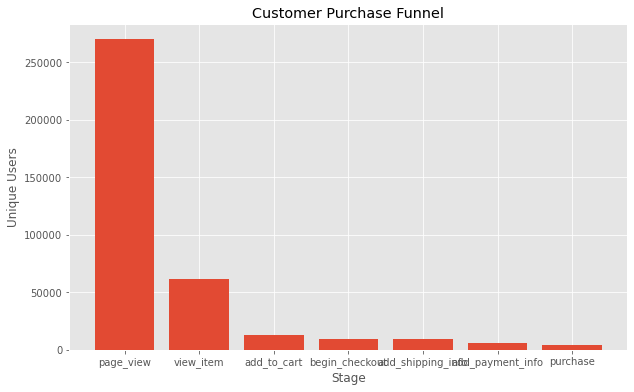

In [25]:
plt.figure(figsize=(10,6))

plt.bar(
    conversion["event_name"],
    conversion["Unique_User"]
)

plt.title("Customer Purchase Funnel")
plt.xlabel("Stage")
plt.ylabel("Unique Users")

plt.show()

# Conversion rate chart

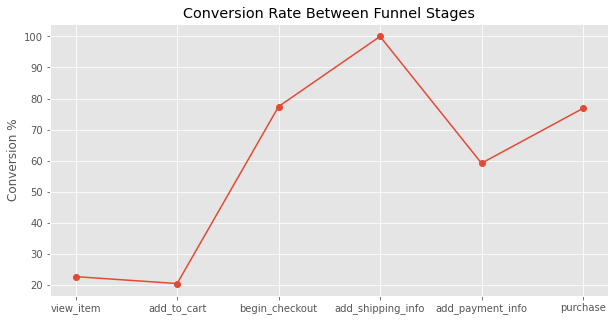

In [27]:
# Conversion rate chart

conversion = conversion.dropna()

plt.figure(figsize=(10,5))

plt.plot(
    conversion["event_name"],
    conversion["adjacent_conversion_rate_pct"],
    marker="o"
)

plt.title("Conversion Rate Between Funnel Stages")

plt.ylabel("Conversion %")

plt.show()

# Root Cause Analysis

## Business Question
Where are customers dropping off in the purchase funnel, and what could be causing it?

### Observation
- Only **22.7%** of users move from **Page View** to **View Item**.
- Only **20.5%** of users move from **View Item** to **Add to Cart**.
- The checkout stages have relatively high conversion rates.

### Possible Causes
- Homepage may not encourage product exploration.
- Product pages may lack compelling descriptions or images.
- Shipping costs or pricing could discourage users from adding items to their cart.
- Marketing campaigns may be attracting low-intent visitors.

### Business Impact
The largest losses occur before users begin checkout, reducing the pool of potential purchasers and ultimately affecting revenue.

### Recommendation
- Improve homepage navigation and product discovery.
- Enhance product pages with better images, descriptions, and reviews.
- Review pricing and shipping strategy.
- Analyze landing pages and marketing campaigns to attract higher-intent traffic.

# traffic source

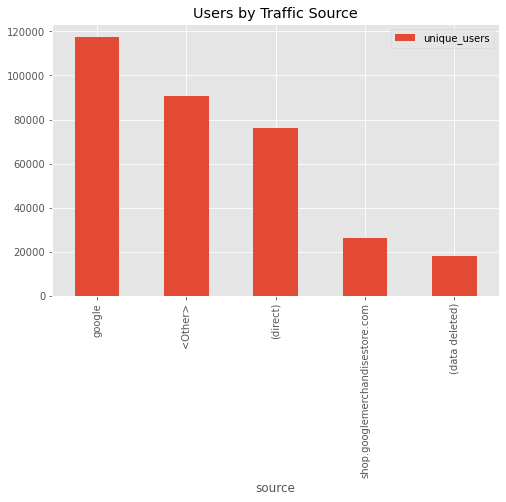

In [30]:
traffic.sort_values(
    "unique_users",
    ascending=False
).plot(
    kind="bar",
    x="source",
    y="unique_users",
    figsize=(8,5)
)

plt.title("Users by Traffic Source")

plt.show()

# country analysis

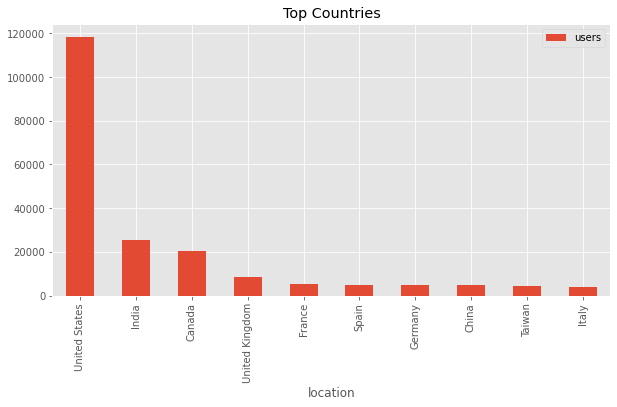

In [33]:
country.head(10).plot(
    kind="bar",
    x="location",
    y="users",
    figsize=(10,5)
)

plt.title("Top Countries")

plt.show()

# device analysis

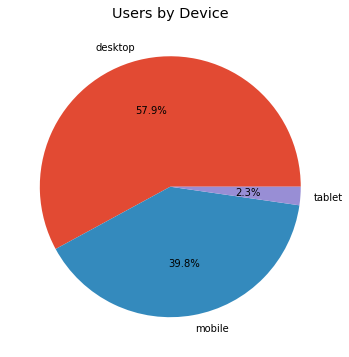

In [34]:
plt.figure(figsize=(6,6))

plt.pie(
    device["users"],
    labels=device["device"],
    autopct="%1.1f%%"
)

plt.title("Users by Device")

plt.show()

# purchase product

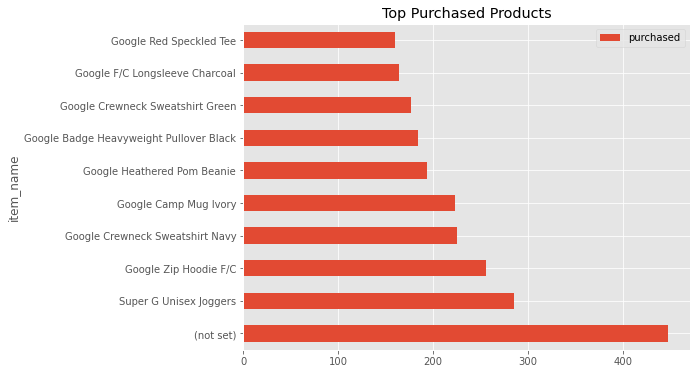

In [35]:
purchase.head(10).plot(
    kind="barh",
    x="item_name",
    y="purchased",
    figsize=(8,6)
)

plt.title("Top Purchased Products")

plt.show()

# revenue analysis

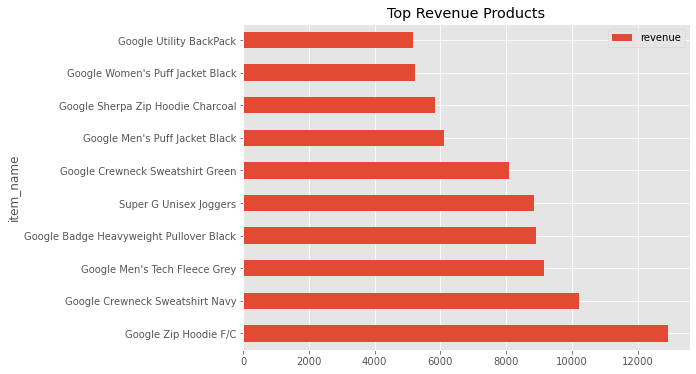

In [36]:
revenue.head(10).plot(
    kind="barh",
    x="item_name",
    y="revenue",
    figsize=(8,6)
)

plt.title("Top Revenue Products")

plt.show()

## Key Business Findings

• Only 22.7% of visitors move from Page View to Product View.

• Around 20.5% of product viewers add items to the cart.

• Checkout completion is high (77%).

• Almost every user enters shipping information once checkout begins.

• The largest customer drop-off occurs before users view products.

• Google is the highest-performing traffic source.

• Desktop users account for the majority of website traffic.

• The United States generates the largest user base.

• Certain products generate high revenue despite not having the highest purchase count, indicating premium pricing or higher-value purchases.